# Text Sentiment Model for Reviews
This notebook focuses on training and saving a model that determines positive or negative sentiment from text. It will do this using TF-IDF methods and a logistic regression model on the following dataset of over 30 million Amazon reviews, which was sourced from the Standford Network Analysis Project (SNAP) and downloaded on Kaggle: https://www.kaggle.com/datasets/kritanjalijain/amazon-reviews.

## 1. Inspecting the Data

In [32]:
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)

Looking at the data, we can see that it is structured in the format polarity (1: negative review, 2: positive review), title, and then text.

In [33]:
def load_data(train_path, test_path):
    """Returns train, test data with labels."""
    col_names = ['label', 'title', 'text']

    train_df = pd.read_csv(train_path, names=col_names)
    test_df = pd.read_csv(test_path, names=col_names)
    return train_df, test_df


def inspect_data(train_df, test_df):
    print(f"Training Data shape: {train_df.shape}\n Testing Data shape: {test_df.shape}")
    print(f"NAs in Training: \n{train_df.isnull().sum()}\n NAs in Testing: \n{test_df.isnull().sum()}")

    print("Unique values in train/test label: ")
    print(train_df['label'].value_counts(normalize=True))
    print(test_df['label'].value_counts(normalize=True))


def validate_data(df):
    df = df.copy()

    # checks for duplicates in both full review and review text
    dup_count = df.duplicated().sum()
    print(f"Number of duplicate rows: {dup_count}")

    dup_text_count = df['text'].duplicated().sum()
    print(f"Number of duplicated reviews: {dup_text_count}")

    # checks review lengths using regex for speed
    df['review_length'] = df['text'].str.count(r'\w+')
    print("Review length stats (by word): ")
    print(df['review_length'].describe())

    # counts reviews under 3 words
    short_reviews = df[df['review_length'] < 3]
    print(f"Number of reviews with less than 3 words: {len(short_reviews)}")
    

In [34]:
train, test = load_data("train.csv", "test.csv")

In [35]:
inspect_data(train, test)

Training Data shape: (3600000, 3)
 Testing Data shape: (400000, 3)
NAs in Training: 
label      0
title    207
text       0
dtype: int64
 NAs in Testing: 
label     0
title    24
text      0
dtype: int64
Unique values in train/test label: 
label
2   0.50
1   0.50
Name: proportion, dtype: float64
label
2   0.50
1   0.50
Name: proportion, dtype: float64


A very small amount of reviews have missing titles, but otherwise there is no missing data. The class balance is perfectly even between positive and negative reviews.

In [36]:
validate_data(train)
validate_data(test)

Number of duplicate rows: 0
Number of duplicated reviews: 5217
Review length stats (by word): 
count   3600000.00
mean         76.52
std          43.80
min           0.00
25%          40.00
50%          68.00
75%         107.00
max         254.00
Name: review_length, dtype: float64
Number of reviews with less than 3 words: 26
Number of duplicate rows: 0
Number of duplicated reviews: 83
Review length stats (by word): 
count   400000.00
mean        76.46
std         43.76
min          2.00
25%         40.00
50%         68.00
75%        106.00
max        222.00
Name: review_length, dtype: float64
Number of reviews with less than 3 words: 1


The validate function tells us that there are very few reviews in both the train and test sets with reviews with a word count under 3, and that the minimum in the training set is 0 (empty review). These reviews could potentially add noise due to sparse text, and can be dropped from the data because they make up a very small amount of it.

There is a potential issue of duplicated reviews. While there are no duplicated complete reviews (including classification, title, and text), there are repeated review texts. These duplicates make up only about .1% of the dataset and could be natural, but could signal issues in data quality. A quick check into this subset could show whether there are duplicate reviews with different classifications: this could confuse the model.

In [37]:
def inspect_duplicate_text(df):
    """More information on the rows with matching review text."""
    df = df.copy()
    # subset that keeps all duplicates
    dups = df[df['text'].duplicated(keep=False)].copy()
    dups.to_csv("dup.csv", index=False)
    grouped = dups.groupby('text')

    # stores where duplicate reviews havae different classifications
    inconsistent_class =  grouped['label'].nunique().loc[lambda x: x > 1]
    conflicting_reviews = dups[dups['text'].isin(inconsistent_class.index)]

    print(f"Matching text, different class: {len(conflicting_reviews)}")

    # stores where duplicate reviews havae different classifications
    inconsistent_title =  grouped['title'].nunique().loc[lambda x: x > 1]
    conflicting_titles = dups[dups['text'].isin(inconsistent_title.index)]

    print(f"Matching text, different titles:  {len(conflicting_titles)}")

    # checks review lengths using regex for speed
    dups['review_length'] = dups['text'].str.count(r'\w+')
    print("Review length stats (by word): ")
    print(dups['review_length'].describe())
    print("\n")


inspect_duplicate_text(train)
inspect_duplicate_text(test)

Matching text, different class: 104
Matching text, different titles:  9494
Review length stats (by word): 
count   9494.00
mean      79.99
std       46.79
min        8.00
25%       38.00
50%       73.00
75%      115.00
max      215.00
Name: review_length, dtype: float64


Matching text, different class: 2
Matching text, different titles:  163
Review length stats (by word): 
count   163.00
mean     76.53
std      43.26
min      14.00
25%      37.00
50%      75.00
75%     106.00
max     182.00
Name: review_length, dtype: float64




Duplicate checks show that most matching review texts differ only in their titles, though occasionally the same review text appears with different labels. Some reviews have clearly been posted multiple times. While duplicates are uncommon, we will remove all but the first occurrence of each review with the same text and title to prevent noise and avoid overrepresenting repeated reviews.

### Cleaning Data
Based on the previous inspection and validation, we can create a cleaning function. It drops reviews with a text word count under three and repeats in both text and title from the train and test sets, and maps the sentiment scores to {0: negative, 1: positive} instead of using {1, 2}, as it is standard for classification problems and many ML models expect binary classes to be 0 and 1.

In [38]:
def clean_data(df):
    df = df.copy()
    df = df[df['text'].str.count(r'\w+') >= 3]
    df = df.drop_duplicates(subset=['text', 'title'], keep='first')
    df['label'] = df['label'].map({1:0, 2:1})
    return df
    

In [39]:
train = clean_data(train)
test = clean_data(test)

For optional additional data cleaning, spelling checks could improve minor errors in reviews. However, this can also be time-consuming and is not necessary for a baseline model.

## Model Pipeline
The pipeline includes a TF-IDF vectorizer and a logistic regression classifier to learn sentiment.
### Feature Extraction using TF-IDF Vectorization
TF-IDF stands for Term Frequency-Inverse Document Frequency. It converts text into numerical features by measuring how often a word appears in a review (term frequency) while down-weighting words that appear in many reviews (inverse document frequency). This highlights words that are important and specific to each review, which improves the model's ability to distinguish sentiment.

Scikit-Learn allows the TfidfVectorizer to be used within pipelines. It will be used with a logistic regression classifier for its simplicity, interpretibility, and strong performance on high dimensional sparse data like TF-IDF vectors.



In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import joblib
from sklearn.metrics import classification_report
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [51]:
def build_tfidf_logreg_pipeline():
    """Returns pipeline with TF-IDF 'tfidf' and logistic regression 'clf'."""
    pipeline = Pipeline([
        # max features of 10,000 to prevent noise
        ('tfidf', TfidfVectorizer(max_features=10000, stop_words = 'english', ngram_range=(1,2), min_df=10, max_df=.85)),
        ('clf', LogisticRegression(max_iter=1000))
    ])
    return pipeline


In [ ]:
def train_sentiment_model(train):
    """Returns fitted model."""
    model = build_tfidf_logreg_pipeline()
    model.fit(train['text'], train['label'])
    return model

In [57]:

def evaluate_model(model, test):
    """Prints a classification report from trained model & test set."""
    preds = model.predict(test['text'])
    print(classification_report(test['label'], preds))


def visualize_metrics(model, test):
    """Visualizes a confusion matrix from trained model & test set."""

    y_pred = model.predict(test['text'])
    cm = confusion_matrix(test['label'], y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
def save_trained_model(model, name):
    joblib.dump(model, name)

In [53]:
# train and save the model
trained_model = train_sentiment_model(train)
save_trained_model(trained_model, "sentiment_model.pkl")

              precision    recall  f1-score   support

           0       0.88      0.87      0.88    200000
           1       0.88      0.88      0.88    199999

    accuracy                           0.88    399999
   macro avg       0.88      0.88      0.88    399999
weighted avg       0.88      0.88      0.88    399999



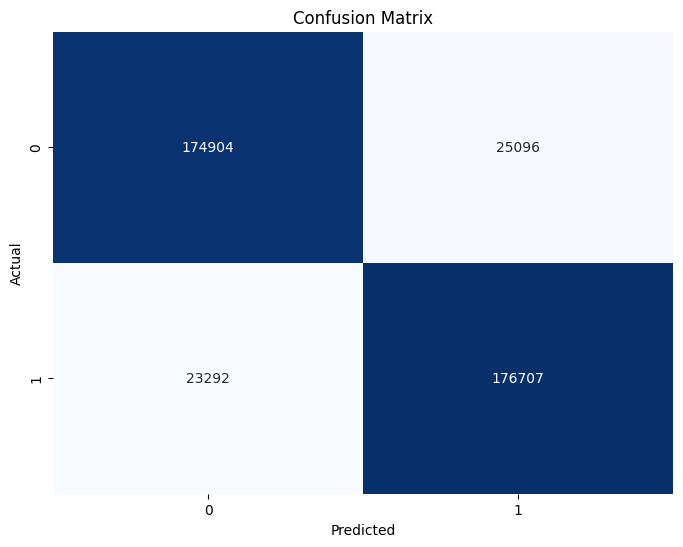

In [ ]:
# print evaluations
evaluate_model(trained_model, test)
visualize_metrics(trained_model, test)

### Evaluation
The model has performs well across both sentiment classes, with accuracy, precision, recall, and F1 of 88%. This indicates that the model reliably distinuishes between positive and negative sentiment without significant bias towards either class. The model also performs well without hyperparamter tuning, which makes it a solid baseline for review-based sentiment analysis. 

Further performance tuning in regularization strength or vectorizer settings could improve results, but the gains are likely to be limited.